<a href="https://colab.research.google.com/github/tahoorak-s/Daily-Electricity-Cost/blob/main/PredictElecCost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Using Regression To Predict Electricity Charges of a Household

###Project Outline

* Downloading and exploring a dataset for machine learning
* Linear regression with multiple variables, including categorical variables
* Training a model and predicting the values


##Problem Statement
 LivAnyWhere (LAW) Pvt Ltd. offers affordable vacational rental houses to thousands of customers all over the United States. As the lead data scientist at LAW , you're tasked with creating an automated system to estimate the daily electricity charges for each customer, using information such as: household size, average temperature of the day, availability of an AC, etc.

Estimates from your system will be used to determine an affordable plan, perfectly aligned with the customer's budget; Similarly, it may used to offer any discounts or bonus deals. Due to regulatory requirements, you must be able to explain why your system outputs a certain prediction.

You're given a CSV file containing verified historical data, consisting of the aforementioned information and the actual household details and energy consumption rates for over 12800 households in the vacation region.

<p>We can now create a Pandas dataframe using the downloaded file, to view and analyze the data.</p>

In [183]:
import pandas as pd
import numpy as np


In [184]:
elec_df = pd.read_csv(r'/household_energy_consumption.csv')

In [185]:
elec_df

,Household_ID,Date,Energy_Consumption_kWh,Household_Size,Avg_Temperature_C,Has_AC,Peak_Hours_Usage_kWh
0,H00001,2025-04-01,8.4,4,17.8,No,3.2
1,H00001,2025-04-02,7.9,4,17.3,No,2.8
2,H00001,2025-04-03,9.2,4,18.6,No,3.0
3,H00001,2025-04-04,7.9,4,18.2,No,2.7
4,H00001,2025-04-05,9.6,4,11.9,No,3.2
...,...,...,...,...,...,...,...
89995,H12857,2025-04-04,5.0,2,19.3,No,1.5
89996,H12857,2025-04-05,5.3,2,16.1,No,1.7
89997,H12857,2025-04-06,4.3,2,14.6,No,1.5
89998,H12857,2025-04-07,7.2,2,18.2,No,2.6


The dataset contains 90000 rows and 7 columns. Each row of the dataset contains information about one household on one day out of the week.

Our objective is to find a way to estimate the value in the "Energy_Consumption_kWh" column using the values in the other columns. If we can do so for the historical data, then we should able to estimate charges for new customers too, simply by asking for information like avg temperature, household size, etc.

Let's check the statistical details for this dataset.

In [186]:
elec_df.describe()

,Energy_Consumption_kWh,Household_Size,Avg_Temperature_C,Peak_Hours_Usage_kWh
count,90000.000000,90000.000000,90000.000000,90000.000000
mean,10.571988,3.487811,17.505802,4.319557
std,5.519494,1.709761,2.491621,2.531432
min,0.500000,1.000000,10.000000,0.200000
25%,6.000000,2.000000,15.800000,2.300000
50%,10.400000,3.000000,17.500000,4.000000
75%,14.800000,5.000000,19.200000,6.000000
max,20.000000,6.000000,25.000000,10.000000


#**ANALYZING THE DATA THROUGH VISUALIZATION**



Let's explore the data by visualizing the distribution of values in some columns of the dataset, and the relationships between "charges" and other columns.

We'll use libraries Matplotlib, Seaborn and Plotly for visualization.

In [187]:
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns


In [188]:
elec_df.Household_Size.describe()

,Household_Size
count,90000.000000
mean,3.487811
std,1.709761
min,1.000000
25%,2.000000
50%,3.000000
75%,5.000000
max,6.000000


#####Histogram Representation of Household Sizes

In [189]:
fig = px.histogram(elec_df,
                   x = 'Household_Size',
                   marginal='box',
                   nbins=47,
                   title='Size Distribution')
fig.update_layout(bargap=0.05)
fig.show()

#####ScatterPlot to Analyze the Relation Between Household Size and the Energy Consumption(kWh)

In [190]:
px.scatter(elec_df,
           x ='Household_Size',
           y = 'Energy_Consumption_kWh',
           title = 'Size vs Consumption')

###Correlation
<p>As you can tell from the analysis, the values in some columns are more closely related to the values in "Energy_Consumption_kWh" compared to other columns. E.g. "Household_Size" and  "Energy_Consumption_kWh" seem to grow together, whereas "Avg_Temperature_C" and " "Energy_Consumption_kWh" don't.

This relationship is often expressed numerically using a measure called the correlation coefficient, which can be computed using the `.corr `method of a Pandas series.</p>

In [191]:
elec_df.Energy_Consumption_kWh.corr(elec_df.Household_Size)

np.float64(0.8939588686892502)

Next, let's visualize the relationship between Household Size and the Energy Consumption(kWh)

<Axes: xlabel='Household_Size', ylabel='Energy_Consumption_kWh'>

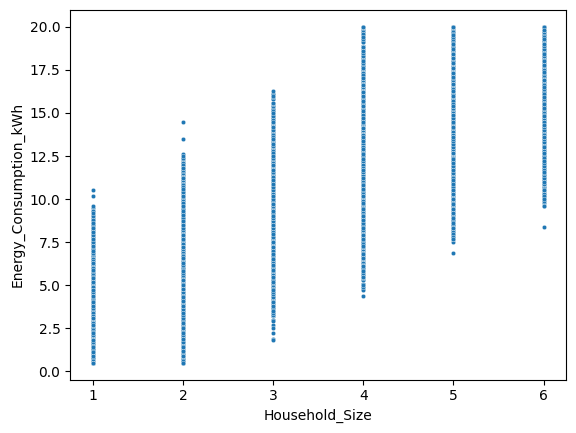

In [192]:
sns.scatterplot(data=elec_df, x= 'Household_Size',y='Energy_Consumption_kWh',s=10)

#Finding the "Best-Fit"
###<u>Model</u>
In the above case, the x axis shows "Household_Size" and the y axis shows "Energy_Consumption_kWh". Thus, we're assuming the following relationship between the two:<br>
 `energy_consumption_kWh = w x "Household_Size" + b`
  
We'll try determine
 and
 for the line that best fits the data.

This technique is called linear regression, and we call the above equation a linear regression model, because it models the relationship between "Household_Size" and "Energy Consumption" as a straight line.

* The numbers
 and
 are called the parameters or weights of the model.

* The values in the "Household_Size" column of the dataset are called the inputs to the model and the values in the Energy_Consumption_kWh column are called "targets".

* Let define a helper function estimate_charges, to compute energy consumption, given household size, w and b.

In [193]:
def estimate_energy(Household_Size, w, b):
  return w * Household_Size + b

This is very first model to estimate the energy consumption

In [245]:
#w = 0
#b = 46

In [231]:
hhs = elec_df.Household_Size
ecr = estimate_energy(hhs, w, b)

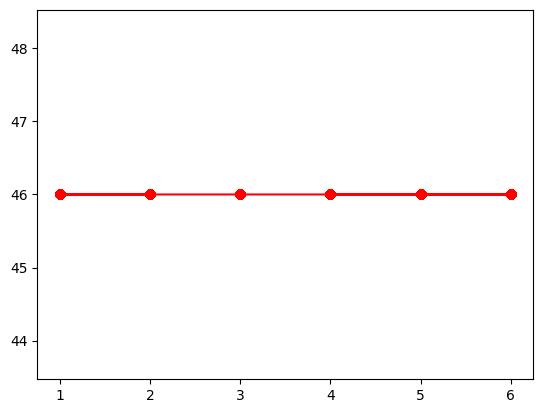

In [232]:
plt.plot(hhs, ecr, 'r-o')

As expected, the points lie on a straight line.

We can overlay this line on the actual data, so see how well our model fits the data.

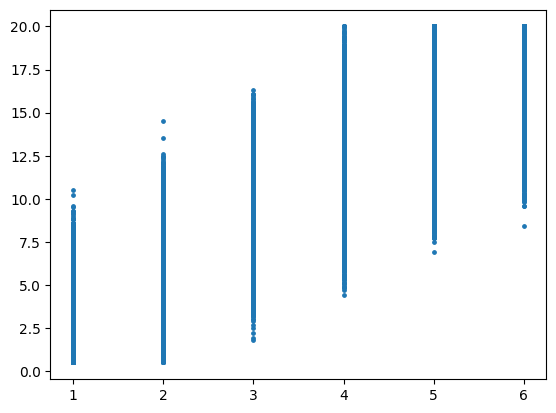

In [233]:
target = elec_df.Energy_Consumption_kWh
plt.scatter(hhs,target,s=6)

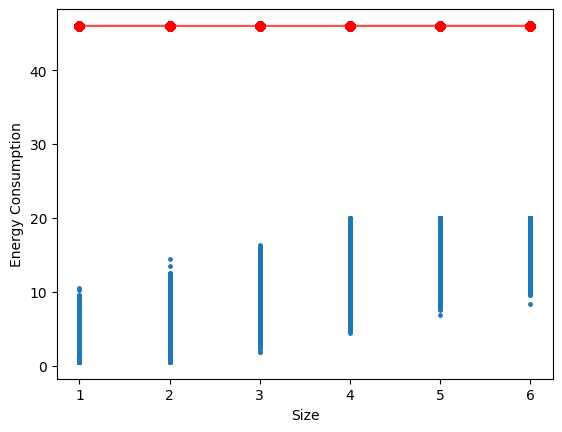

In [234]:
target = elec_df.Energy_Consumption_kWh
plt.plot(hhs, ecr, 'r-o',alpha=0.7)
plt.scatter(hhs,target,s=6)
plt.xlabel('Size');
plt.ylabel("Energy Consumption");

Clearly, the our estimates are quite poor and the line does not "fit" the data. However, we can try different values of w
 and b
 to move the line around. Let's define a helper function `try_parameters` which takes w and b as inputs and creates the above plot.

In [198]:
def try_parameters(w, b):
  Household_Sizes = elec_df.Household_Size
  target = elec_df.Energy_Consumption_kWh

  ecr = estimate_energy(hhs, w, b)

  plt.plot(hhs,ecr, 'r-o',alpha=0.7)
  plt.scatter(hhs,target,s=6)
  plt.xlabel('Size');
  plt.ylabel("Energy Consumption")

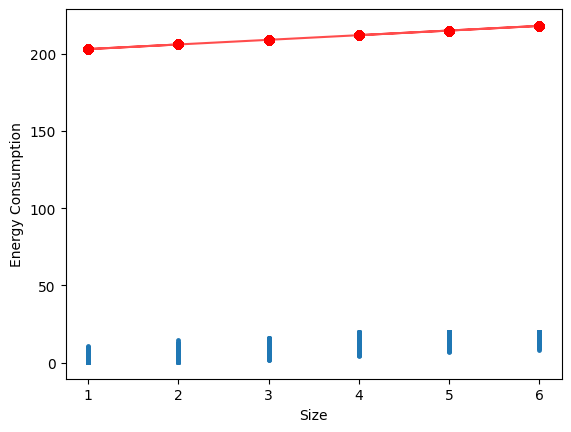

In [199]:
try_parameters(3,200)

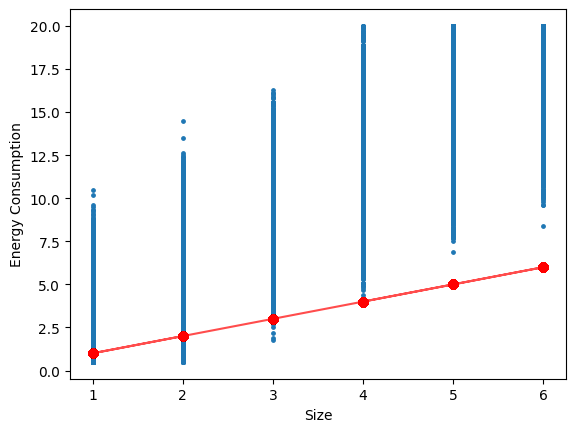

In [200]:
try_parameters(1,-0)

#BEST FIT PARAMETERS


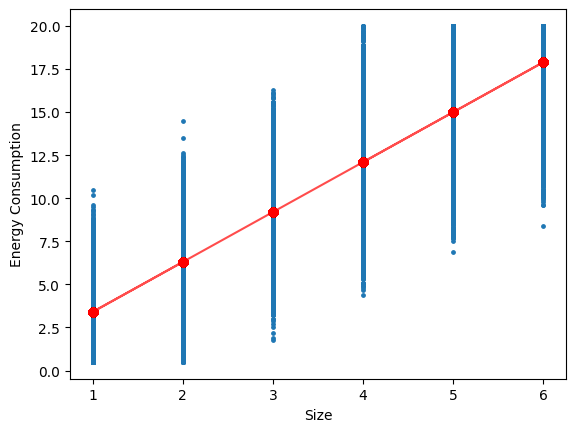

In [201]:
try_parameters(2.9,0.5)

In [235]:
w =2.9
b =0.5

###**Loss Function**
We can compare our model's predictions with the actual targets using the following method:

* Calculate the difference between the targets and predictions (the differenced is called the "residual")
* Square all elements of the difference matrix to remove negative values.
* Calculate the average of the elements in the resulting matrix.
* Take the square root of the result
* The result is a single number, known as the root mean squared error (RMSE). The above description can be stated mathematically as follows:
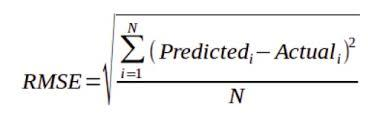

Let's define a function to compute the RMSE.

In [239]:
def rmse(targets, predictions):
  return np.sqrt(np.mean(np.square(targets - predictions)))

In [240]:
targets = elec_df['Energy_Consumption_kWh']
predicted = estimate_energy(elec_df.Household_Size, w, b)

In [242]:
rmse(targets, predicted)

np.float64(2.4740276204332616)

In [243]:
def try_parameters(w, b):
    hhs = elec_df.Household_Size
    target = elec_df.Energy_Consumption_kWh
    predictions = estimate_energy(hhs, w, b)

    plt.plot(hhs, predictions, 'r', alpha=0.9);
    plt.scatter(hhs, target, s=8,alpha=0.8);
    plt.xlabel('Size');
    plt.ylabel('Energy Consumption')
    plt.legend(['Prediction', 'Actual']);

    loss = rmse(targets, predictions)
    print("RMSE LOSS:" ,loss)

#Linear Regression using Scikit-learn
In practice, you can use a library like `scikit-learn` to do this for you.

In [207]:
from sklearn.linear_model import LinearRegression

In [208]:
model = LinearRegression()
model

LinearRegression()

In [209]:
inputs = elec_df[['Household_Size']]
targets = elec_df.Energy_Consumption_kWh
print('Inputs.Shape:',inputs.shape)
print('Targets.Shape:',targets.shape)

Inputs.Shape: (90000, 1)
Targets.Shape: (90000,)


In [210]:
model.fit(inputs, targets)

LinearRegression()

In [211]:
model.predict(np.array([[3],
                       [1],
                       [6]]))

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



array([ 9.1642135 ,  3.39241272, 17.82191468])

In [212]:
inputs

,Household_Size
0,4
1,4
2,4
3,4
4,4
...,...
89995,2
89996,2
89997,2
89998,2


In [213]:
predictions = model.predict(inputs)

In [214]:
predictions

array([12.05011389, 12.05011389, 12.05011389, ...,  6.27831311,
        6.27831311,  6.27831311])

In [215]:
rmse(targets, predictions)

np.float64(2.4735422520256622)

In [216]:
model.intercept_

np.float64(0.506512324495759)

#Linear Regression using Multiple Features

Previously, we just used household size to predict the energy consumption but now we will use another parameter.
For instance, we will now use average temperature as our second parameter to predict the energy consumption in kWh.

###Checking the correlation of average temperature with Energy Consumption

In [217]:
elec_df.Energy_Consumption_kWh.corr(elec_df.Avg_Temperature_C)

np.float64(0.03331481373972667)

Obviously, the correlation isn't much; hence the difference in loss function wouldn't be much, either.

In [218]:
px.scatter(elec_df, x='Avg_Temperature_C',y='Energy_Consumption_kWh')

In [219]:
model.coef_, model.intercept_

(array([2.88590039]), np.float64(0.506512324495759))

In [220]:
# create inputs and targets
inputs, targets = elec_df[['Household_Size','Avg_Temperature_C']], elec_df['Energy_Consumption_kWh']

# create and train model
model = LinearRegression().fit(inputs, targets)

# Generate predictions
predictions = model.predict(inputs)

# compute the loss
loss = rmse(targets, predictions)
print('Loss: ',loss)

Loss:  2.4670608081969294


###Using Categorical Values for Training the Dataset

So far, we've only been using numerical values to train the datasets. Now let us try with a categorical value- 'Has AC' and see if there are any changes in the loss function.

<Axes: xlabel='Has_AC', ylabel='Energy_Consumption_kWh'>

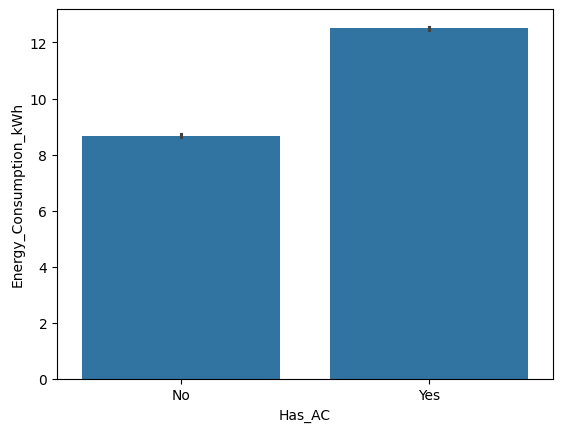

In [221]:
sns.barplot(data=elec_df, x='Has_AC',y ='Energy_Consumption_kWh')

In [222]:
#changing the binary values of the column 'Has_AC' to 0 and 1
elec_codes = {'No':0, 'Yes': 1}
elec_df['elec_code'] = elec_df.Has_AC.map(elec_codes)

In [223]:
elec_df

,Household_ID,Date,Energy_Consumption_kWh,Household_Size,Avg_Temperature_C,Has_AC,Peak_Hours_Usage_kWh,elec_code
0,H00001,2025-04-01,8.4,4,17.8,No,3.2,0
1,H00001,2025-04-02,7.9,4,17.3,No,2.8,0
2,H00001,2025-04-03,9.2,4,18.6,No,3.0,0
3,H00001,2025-04-04,7.9,4,18.2,No,2.7,0
4,H00001,2025-04-05,9.6,4,11.9,No,3.2,0
...,...,...,...,...,...,...,...,...
89995,H12857,2025-04-04,5.0,2,19.3,No,1.5,0
89996,H12857,2025-04-05,5.3,2,16.1,No,1.7,0
89997,H12857,2025-04-06,4.3,2,14.6,No,1.5,0
89998,H12857,2025-04-07,7.2,2,18.2,No,2.6,0


In [224]:
elec_df.Energy_Consumption_kWh.corr(elec_df.elec_code)

np.float64(0.34692142559877837)

In [225]:
# create inputs and targets
inputs, targets = elec_df[['Household_Size','Avg_Temperature_C','elec_code']], elec_df['Energy_Consumption_kWh']

# create and train model
model = LinearRegression().fit(inputs, targets)

# Generate predictions
predictions = model.predict(inputs)

# compute the loss
loss = rmse(targets, predictions)
print('Loss: ',loss)


Loss:  1.61077034858507


In [226]:
predictions

array([10.2184061 , 10.18210296, 10.27649112, ...,  4.23505685,
        4.49643944,  4.49643944])

#Final Observation



In [227]:
from sklearn.ensemble import RandomForestRegressor

In [228]:
inputs, targets = elec_df[['Household_Size','Avg_Temperature_C','elec_code']], elec_df['Energy_Consumption_kWh']

# create and train model
model_rf = RandomForestRegressor().fit(inputs, targets)

# Generate predictions
predictions = model_rf.predict(inputs)

# compute the loss
loss = rmse(targets, predictions)
print('Loss: ',loss)

Loss:  1.4099556245474365


Based on the standard electricity rate in the United States—approximately 16.44 cents per kilowatt-hour (or about \$0.17)—let’s estimate the daily cost of energy use, taking into account household size, average temperature, and whether the home has an air conditioner.


In [247]:
float(model_rf.predict([[6,20,1]]))*0.17

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but RandomForestRegressor was fitted with feature names

<ipython-input-247-4df33abc2c07>:1: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)



3.3963026776087335

Therefore, for a household of 6 people with an air conditioner, on a day when the temperature is 20°C, the estimated daily energy consumption would be around 3.396 kWh, costing approximately \$4.


---
## Conclusion

In this project, we successfully built a regression-based model to predict the daily electricity charges for households using key features such as household size, average temperature, and air conditioner availability. By analyzing a dataset of over 12,800 verified records, we trained a multivariable linear regression model capable of making accurate and explainable predictions.

The model provides a valuable tool for LivAnyWhere (LAW) Pvt Ltd. to offer personalized and budget-friendly rental plans to its customers. It also supports regulatory compliance by allowing transparent interpretation of each prediction. This solution not only enhances customer satisfaction by anticipating energy costs but also enables LAW to deliver dynamic offers and discounts efficiently.

Future improvements could include incorporating additional variables—such as appliance usage and insulation quality—or extending the model to calculate the total electricity cost based on the duration of a customer’s stay. Nonetheless, our current system lays a strong foundation for intelligent, data-driven decision-making in vacation rental energy planning.
